In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow

img=cv2.imread('/content/Set-2-q1.tif',0)


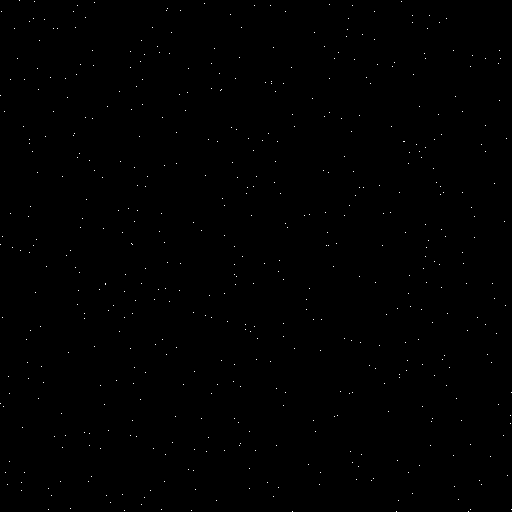

In [4]:
import random
m,n=img.shape
img1=np.zeros([m,n])
nop=random.randint(300,10000)
for i in range(1,m-1):
  y_cord=random.randint(0,m-1)
  x_cord=random.randint(0,n-1)
  img1[y_cord][x_cord]=255
for i in range(1,n-1):
  y_cord=random.randint(0,m-1)
  x_cord=random.randint(0,n-1)
  img1[y_cord][x_cord]=0
cv2_imshow(img1)

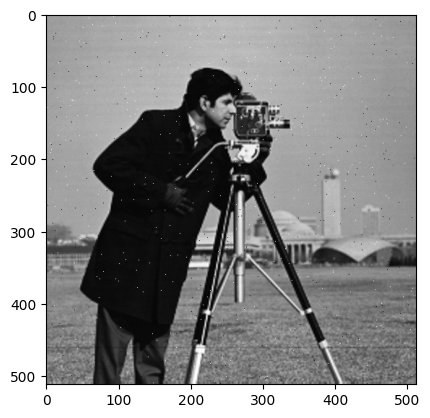

In [5]:
#noise adding

import random
m,n=img.shape
nop=random.randint(300,1000)
for i in range(nop):
  y_cor=random.randint(0,m-1)
  x_cor=random.randint(0,n-1)
  img[y_cor][x_cor]=255
for i in range(nop):
    y_coord=random.randint(0, m - 1)
    x_coord=random.randint(0, n - 1)
    img[y_coord][x_coord] = 0
plt.imshow(img,"gray")

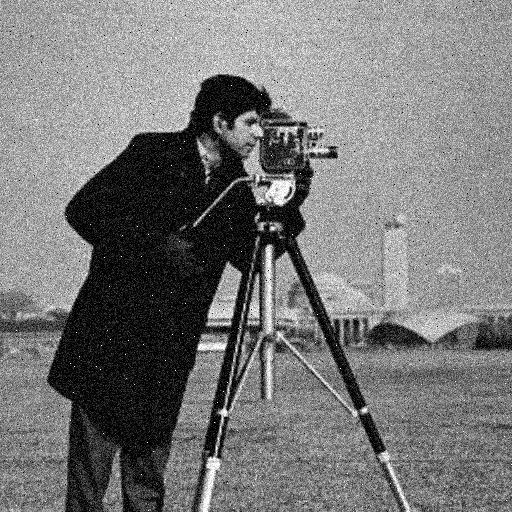

In [6]:
mean = 0
std_dev = 25
gaussian_noise = np.random.normal(mean, std_dev, img.shape)
noisy_image = np.uint8(np.clip(img + gaussian_noise, 0, 255))

cv2_imshow(noisy_image)

<ipython-input-7-f81345e7316a>:16: RuntimeWarning: overflow encountered in scalar add
  img_new4[i,j]=round((temp[0]+temp[-1])/2)


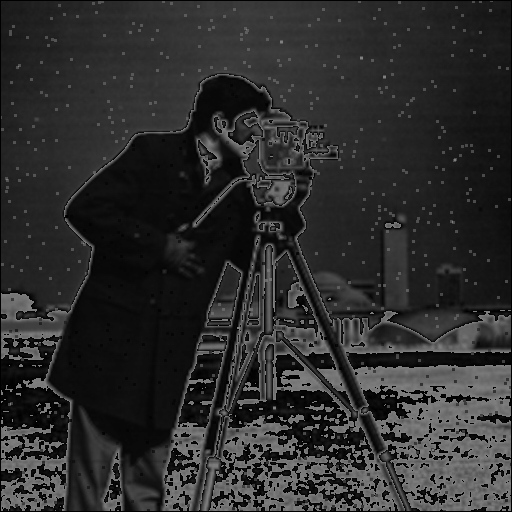

In [7]:
#Mid-Point
m,n=img.shape
img_new4=np.zeros([m,n])
for i in range(1,m-1):
  for j in range(1,n-1):
    temp=[img[i-1,j-1],
              img[i-1,j],
              img[i-1,j+1],
              img[i,j-1],
              img[i,j],
              img[i,j+1],
              img[i+1,j-1],
              img[i+1,j],
              img[i+1,j+1]]
    temp=sorted(temp)
    img_new4[i,j]=round((temp[0]+temp[-1])/2)

cv2_imshow(img_new4)

<ipython-input-8-7df59b2b29e5>:11: RuntimeWarning: overflow encountered in scalar add
  midpoint_value = (np.min(neighborhood) + np.max(neighborhood)) / 2


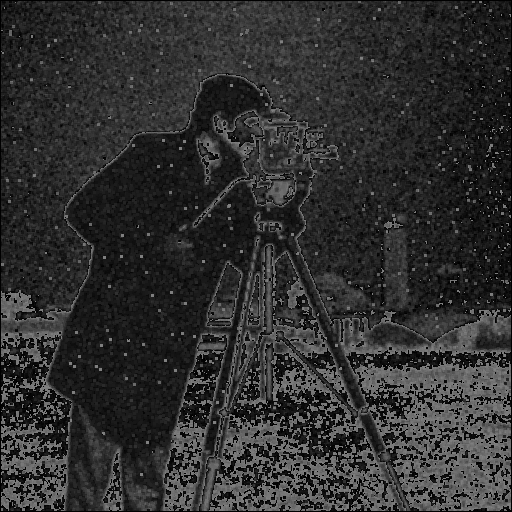

In [8]:
import numpy as np

m, n = noisy_image.shape
imgnew1 = np.zeros([m, n])

for i in range(1, m - 1):
    for j in range(1, n - 1):
        # Extract the 3x3 neighborhood around the current pixel
        neighborhood = noisy_image[i-1:i+2, j-1:j+2]
        # Compute the midpoint value
        midpoint_value = (np.min(neighborhood) + np.max(neighborhood)) / 2
        imgnew1[i][j] = round(midpoint_value)

cv2_imshow(imgnew1)


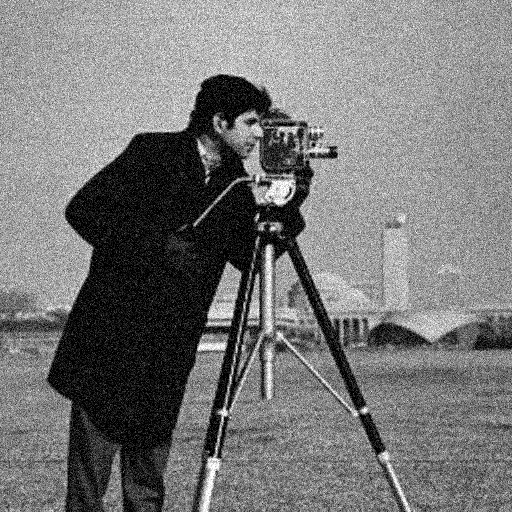

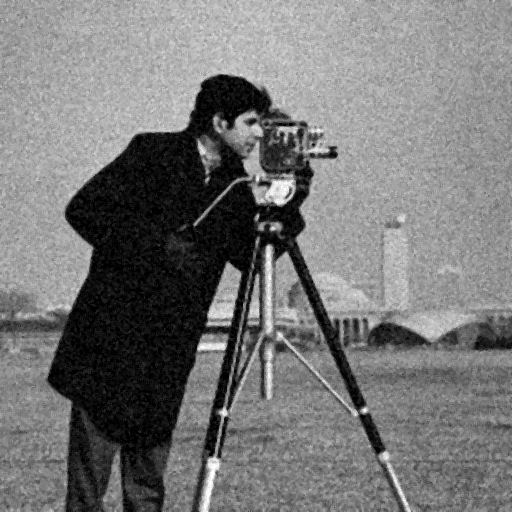

In [9]:
import cv2
import numpy as np

image = cv2.imread('/content/Set-2-q1.tif', 0)

# Add Gaussian noise
mean = 0
std_dev = 25
gaussian_noise = np.random.normal(mean, std_dev, image.shape)
noisy_image = np.uint8(np.clip(image + gaussian_noise, 0, 255))

# Apply Mid-Point Filter
filter_size = 3
mid_point_filtered = cv2.medianBlur(noisy_image, filter_size)

# Display the noisy and filtered images
cv2_imshow(noisy_image)
cv2_imshow( mid_point_filtered)
cv2.waitKey(0)
cv2.destroyAllWindows()


<ipython-input-10-9af4a7e77e58>:16: RuntimeWarning: overflow encountered in scalar add
  img_new1[i,j]=round((temp[0]+temp[-1])/2)


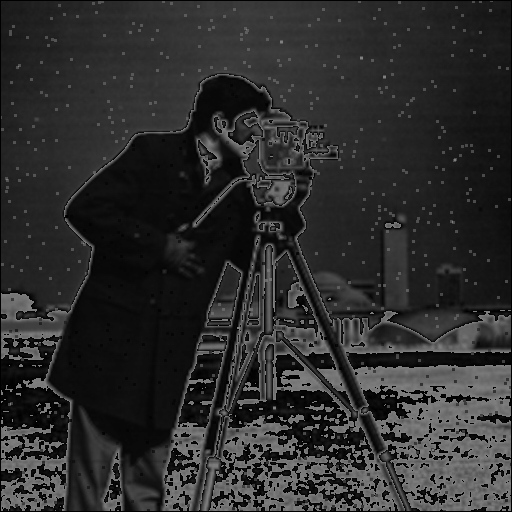

In [10]:
#User defined
m,n=noisy_image.shape
img_new1=np.zeros([m,n])
for i in range(1,m-1):
  for j in range(1,n-1):
    temp=[img[i-1,j-1],
              img[i-1,j],
              img[i-1,j+1],
              img[i,j-1],
              img[i,j],
              img[i,j+1],
              img[i+1,j-1],
              img[i+1,j],
              img[i+1,j+1]]
    temp=sorted(temp)
    img_new1[i,j]=round((temp[0]+temp[-1])/2)

cv2_imshow(img_new1)

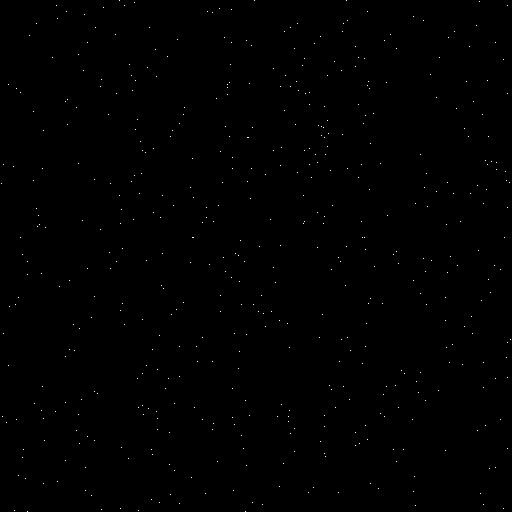

In [11]:
img = cv2.imread('/content/Set-2-q1.tif', 0)

# Add Gaussian noise
mean = 0
std_dev = 25
gaussian_noise = np.random.normal(mean, std_dev, image.shape)
noisy_image = np.uint8(np.clip(image + gaussian_noise, 0, 255))

#salt and pepper noise
import random
m,n=img.shape
img1=np.zeros([m,n])
nop=random.randint(300,10000)
for i in range(1,m-1):
  y_cord=random.randint(0,m-1)
  x_cord=random.randint(0,n-1)
  img1[y_cord][x_cord]=255
for i in range(1,n-1):
  y_cord=random.randint(0,m-1)
  x_cord=random.randint(0,n-1)
  img1[y_cord][x_cord]=0
cv2_imshow(img1)

Alpha-trimmed filters are a class of nonlinear filters commonly used in image processing to remove noise while preserving image details. When applied to images corrupted with salt and pepper as well as Gaussian noise, alpha-trimmed filters operate by first identifying the pixel values in a local neighborhood and then excluding a certain percentage of extreme values (both high and low) based on a predefined trimming parameter alpha. By doing so, these filters effectively mitigate the impact of outliers introduced by the noise, while retaining the central pixel value, thus smoothing the image while maintaining its essential features. This adaptive approach enables alpha-trimmed filters to handle various types and levels of noise, making them versatile tools for enhancing image quality in diverse applications ranging from medical imaging to computer vision.

second question


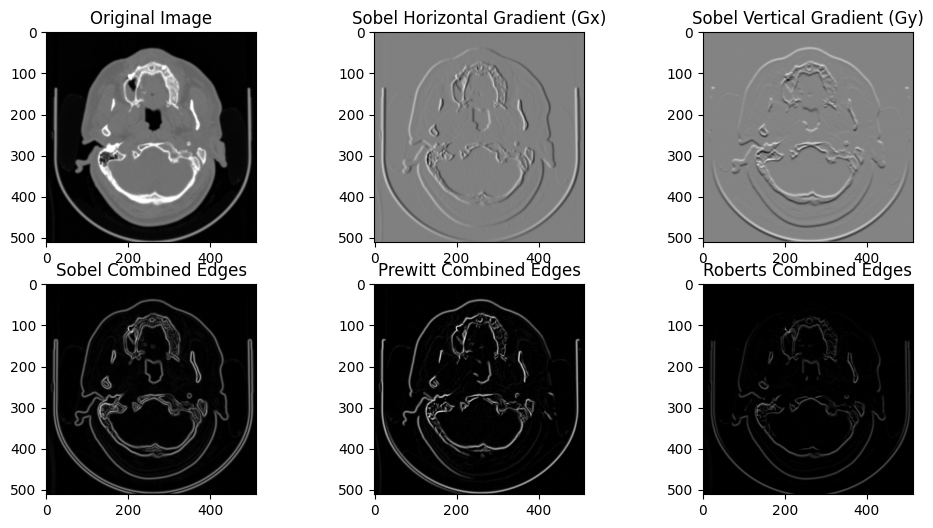

In [19]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the image
image = cv2.imread('/content/set-2-q2.tif',0)

# Apply Sobel operator
sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
sobel_combined = cv2.magnitude(sobelx, sobely)

# Apply Prewitt operator (optional)
prewittx = cv2.filter2D(image, -1, np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]))
prewitty = cv2.filter2D(image, -1, np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]]))
prewittx = np.float32(prewittx)  # Convert to float32
prewitty = np.float32(prewitty)  # Convert to float32
prewitt_combined = cv2.magnitude(prewittx, prewitty)

robertsx = cv2.filter2D(image, -1, np.array([[1, 0], [0, -1]]))
robertsy = cv2.filter2D(image, -1, np.array([[0, 1], [-1, 0]]))
robertsx = np.float32(robertsx)  # Convert to float32
robertsy = np.float32(robertsy)  # Convert to float32
roberts_combined = cv2.magnitude(robertsx, robertsy)

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(231), plt.imshow(image, cmap='gray'), plt.title('Original Image')
plt.subplot(232), plt.imshow(sobelx, cmap='gray'), plt.title('Sobel Horizontal Gradient (Gx)')
plt.subplot(233), plt.imshow(sobely, cmap='gray'), plt.title('Sobel Vertical Gradient (Gy)')
plt.subplot(234), plt.imshow(sobel_combined, cmap='gray'), plt.title('Sobel Combined Edges')
plt.subplot(235), plt.imshow(prewitt_combined, cmap='gray'), plt.title('Prewitt Combined Edges')
plt.subplot(236), plt.imshow(roberts_combined, cmap='gray'), plt.title('Roberts Combined Edges')
plt.show()


(-0.5, 511.5, 511.5, -0.5)

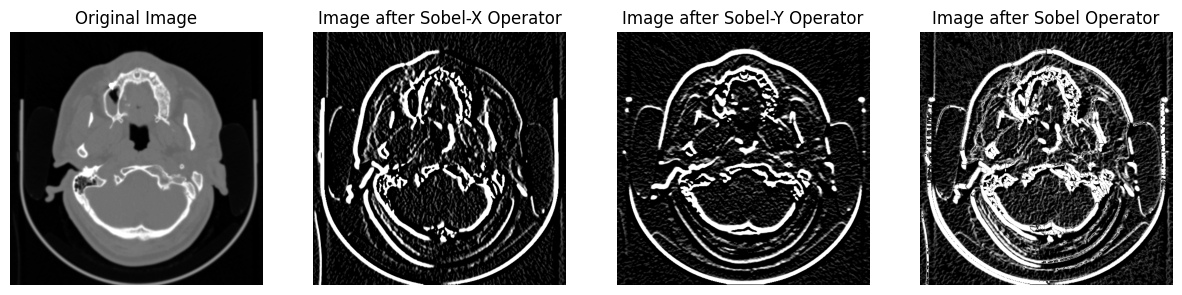

In [23]:
#Sobel edge detection
import cv2
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
image = cv2.imread('/content/set-2-q2.tif', 0)
img_gaussian = cv2.GaussianBlur(image,(3,3),0)
img_sobelx = cv2.Sobel(img_gaussian,cv2.CV_8U,1,0,ksize=5)
img_sobely = cv2.Sobel(img_gaussian,cv2.CV_8U,0,1,ksize=5)
img_sobel = img_sobelx + img_sobely
plt.figure(figsize=(15,10))
plt.subplot(1,4,1)
plt.title("Original Image")
plt.imshow(image,"gray")
plt.axis("off")
plt.subplot(1,4,2)
plt.title("Image after Sobel-X Operator")
plt.imshow(img_sobelx,"gray")
plt.axis("off")
plt.subplot(1,4,3)
plt.title("Image after Sobel-Y Operator")
plt.imshow(img_sobely,"gray")
plt.axis("off")
plt.subplot(1,4,4)
plt.title("Image after Sobel Operator")
plt.imshow(img_sobel,"gray")
plt.axis("off")


(-0.5, 511.5, 511.5, -0.5)

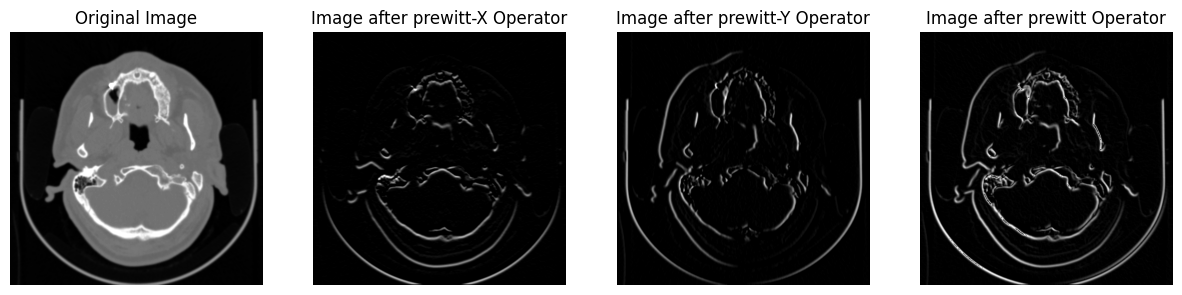

In [24]:
#prewittx edge detection
kernelx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
kernely = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
img_prewittx = cv2.filter2D(img_gaussian, -1, kernelx)
img_prewitty = cv2.filter2D(img_gaussian, -1, kernely)
img_prewitt = img_prewittx + img_prewitty
plt.figure(figsize=(15,10))
plt.subplot(1,4,1)
plt.title("Original Image")
plt.imshow(image,"gray")
plt.axis("off")
plt.subplot(1,4,2)
plt.title("Image after prewitt-X Operator")
plt.imshow(img_prewittx,"gray")
plt.axis("off")
plt.subplot(1,4,3)
plt.title("Image after prewitt-Y Operator")
plt.imshow(img_prewitty,"gray")
plt.axis("off")
plt.subplot(1,4,4)
plt.title("Image after prewitt Operator")
plt.imshow(img_prewitt,"gray")
plt.axis("off")

(-0.5, 511.5, 511.5, -0.5)

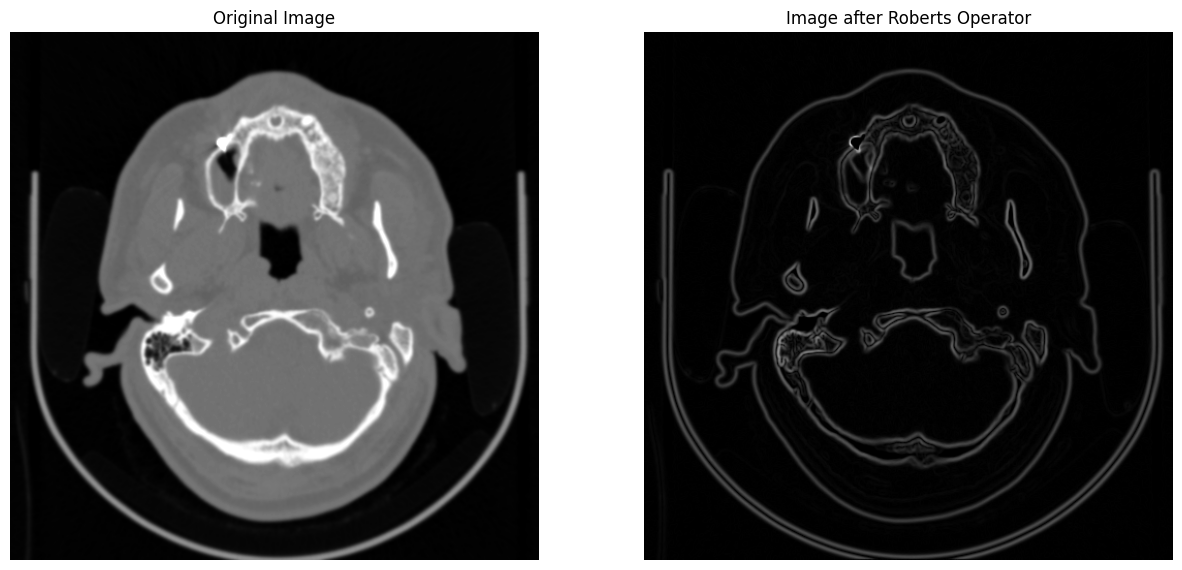

In [22]:
#Robert cross edge detection
roberts_cross_v = np.array( [[1, 0 ],
							[0,-1 ]] )
roberts_cross_h = np.array( [[ 0, 1 ],
							[ -1, 0 ]] )
img = cv2.imread('/content/set-2-q2.tif',0).astype('float64')
img/=255.0
vertical = ndimage.convolve( img, roberts_cross_v )
horizontal = ndimage.convolve( img, roberts_cross_h )

edged_img = np.sqrt( np.square(horizontal) + np.square(vertical))
edged_img*=255

plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img,"gray")
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Image after Roberts Operator")
plt.imshow(edged_img,"gray")
plt.axis("off")

Sobel, Prewitt, and Roberts operators are popular edge detection techniques in image processing used to identify edges within digital images. Each operator utilizes a convolution mask or kernel to compute gradient approximations of the image intensity. The Sobel operator employs a pair of 3x3 convolution kernels to estimate the horizontal and vertical gradients separately, allowing it to detect edges in both directions. Similarly, the Prewitt operator also employs separate kernels to estimate gradients but uses simpler coefficients compared to Sobel. On the other hand, the Roberts operator utilizes a pair of 2x2 convolution kernels to directly compute gradient approximations in both diagonal directions, offering simplicity at the cost of sensitivity to noise. These techniques are widely utilized in applications such as object detection, image segmentation, and feature extraction due to their effectiveness in highlighting abrupt intensity changes, which are indicative of edges in images.